# Artefato 6: Avaliação Experimental - CNN para Classificação de Imagens ASTER

Notebook técnico narrativo para documentação, avaliação e comparação de todos os experimentos CNN realizados com o dataset de imagens multiespectrais ASTER.

### O que cada seção deste notebook faz

**Seção 1 (Objetivo e Escopo)** define o propósito da avaliação experimental: documentar todos os experimentos CNN, comparar configurações e fornecer evidência técnica para seleção do modelo final.

**Seção 2 (Imports e Configuração)** prepara o ambiente, define caminhos e carrega bibliotecas necessárias para reprodução.

**Seção 3 (Descrição do Dataset)** documenta as características do dataset utilizado: dimensões, distribuição de classes, normalização e split treino/validação.

**Seção 4 (Arquitetura CNN)** descreve a arquitetura do modelo, justificativa de cada hiperparâmetro e diagrama das camadas.

**Seção 5 (Catálogo de Configurações)** lista todas as configurações experimentais testadas (baseline, higher_dropout, l2batch, l2batch32, l2batch128, deeper_arch) com tabela comparativa de hiperparâmetros.

**Seção 6 (E1 - Experimento Baseline)** apresenta os resultados detalhados do experimento principal: curvas de aprendizado, métricas de validação, matriz de confusao e análise de overfitting.

**Seção 6b (E4 - Experimento Arquitetura)** avalia o impacto de adicionar uma terceira camada convolucional (deeper_arch: [32, 64, 128]) comparando com o baseline (2 Conv).

**Seção 7 (Histórico Completo de Experimentos)** consolida todos os experimentos realizados em tabela comparativa e gráficos.

**Seção 8 (Comparação com Baselines Anteriores)** compara o desempenho da CNN (A06) com os modelos clássicos (A02) e MLP (A03).

**Seção 9 (Verificação de Artefatos)** valida que todos os artefatos (model.keras, history.json, gráficos) foram gerados corretamente.

**Seção 10 (Conclusões e Próximos Passos)** sintetiza os achados, diagnostica limitações e propõe ações futuras.

---

## 1. Objetivo e Escopo

Este artefato documenta a **avaliação experimental sistemática** dos modelos CNN treinados para classificação binária de imagens multiespectrais ASTER (Advanced Spaceborne Thermal Emission and Reflection Radiometer). O dataset contem tiles de 128x128 pixels com 9 bandas espectrais, e o objetivo é classificar cada tile como pertencente a classe positiva (presença do fenômeno de interesse) ou negativa.

### Contexto no Pipeline do Projeto

| Artefato | Descrição | Status |
|---|---|---|
| **A01** | EDA e Pipeline de Dados | Concluído |
| **A02** | Baseline Classico (ML Tradicional) | Concluído |
| **A03** | Baseline MLP | Concluído |
| **A04** | Preparação de Dados para CNN | Concluído |
| **A05** | Treinamento CNN | Concluído |
| **A06** | **Avaliação Experimental (este notebook)** | **Atual** |

### Perguntas que este artefato responde

1. O modelo baseline CNN (E1) é capaz de classificar corretamente as imagens ASTER?
2. Quais sao as métricas detalhadas de desempenho (precision, recall, F1, AUC-ROC)?
3. Ha evidência de overfitting? Qual a magnitude?
4. Como o desempenho da CNN se compara com os baselines anteriores (A02, A03)?
5. Quais configurações foram testadas e como se comparam?

---
## 2. Imports e Configuração

In [ ]:
# adiciona a raiz do repo no sys.path (funciona no VS Code é no Colab)
from pathlib import Path
import sys

repo_root = Path().resolve()
while repo_root != repo_root.parent and not (repo_root / "src").exists():
    repo_root = repo_root.parent
if (repo_root / "src").exists():
    sys.path.insert(0, str(repo_root))
else:
    raise RuntimeError("Não encontrei a pasta 'src' acima do diretório atual.")

In [ ]:
import os
import json
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import tensorflow as tf
from tensorflow import keras

# Configuração de estilo
SEED = 42
plt.rcParams.update({
    'figure.figsize': (12, 6),
    'font.size': 12,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'legend.fontsize': 11,
    'figure.dpi': 100,
})
sns.set_style('whitegrid')

# Caminhos do projeto
PROJECT_ROOT = repo_root
MODELS_DIR = PROJECT_ROOT / 'outputs' / 'trained_models'
OUTPUT_DIR = PROJECT_ROOT / 'outputs' / 'a06_avaliação_experimental'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f'Repositório: {PROJECT_ROOT}')
print(f'Modelos:     {MODELS_DIR}')
print(f'Saida:       {OUTPUT_DIR}')
print(f'TensorFlow:  {tf.__version__}')

Repositório: /Users/mateus/Projetos/Academico/Inteli/g01
Modelos:     /Users/mateus/Projetos/Academico/Inteli/g01/outputs/trained_models
Saida:       /Users/mateus/Projetos/Academico/Inteli/g01/outputs/a06_avaliação_experimental
TensorFlow:  2.20.0


---
## 3. Descrição do Dataset

O dataset foi construido no Artefato A04 (Preparação de Dados para CNN) a partir de imagens multiespectrais do sensor ASTER. Cada amostra é um tile de 128x128 pixels com 9 bandas espectrais, normalizado via Z-score com estatísticas pre-computadas.

<strong>Tabela 1</strong> - Caracteristicas do Dataset

| Propriedade | Valor |
|---|---|
| **Formato de Entrada** | 128 x 128 x 9 (altura x largura x bandas) |
| **Tipo de Problema** | Classificação Binaria |
| **Total de Amostras** | 295 (apos remocao de labels invalidos) |
| **Classe 0 (Negativo)** | 179 amostras (60.7%) |
| **Classe 1 (Positivo)** | 116 amostras (39.3%) |
| **Normalização** | Z-score (pré-computado: média e desvio padrão por banda) |
| **Split Treino/Val** | 80% / 20% (236 treino, 59 validação) |
| **Arquivo do Dataset** | `data/pixels_dataset.csv` |
| **Normalizador** | `outputs/a04_cnn_data_prep/cnn_normalizer_zscore.npz` |

<p style="font-size: 0.9em;">Fonte: Pipeline de preparação de dados (A04).</p>

In [ ]:
# Validação dos dados de entrada
dataset_path = PROJECT_ROOT / 'data' / 'pixels_dataset.csv'
codes_path = PROJECT_ROOT / 'data' / 'extracted_codes.json'
normalizer_path = PROJECT_ROOT / 'outputs' / 'a04_cnn_data_prep' / 'cnn_normalizer_zscore.npz'

df_raw = pd.read_csv(dataset_path)
with open(codes_path) as f:
    codes = json.load(f)

print(f'Dataset shape: {df_raw.shape}')
print(f'Total de colunas: {len(df_raw.columns)} (features pixel + metadados)')
print(f'\nCodigos positivos: {len(codes.get("positivos", []))} imagens')
print(f'Codigos negativos: {len(codes.get("negativos", []))} imagens')
print(f'\nNormalizador: {"OK" if normalizer_path.exists() else "NÃO ENCONTRADO"}')

# Distribuição de classes
print(f'\nDistribuição no dataset bruto: {len(df_raw)} amostras')

Dataset shape: (295, 147464)
Total de colunas: 147464 (features pixel + metadados)

Codigos positivos: 116 imagens
Codigos negativos: 199 imagens

Normalizador: OK

Distribuição no dataset bruto: 295 amostras


---
## 4. Arquitetura do Modelo CNN

A arquitetura CNN segue o padrao classico inspirado em LeCun et al. (1998) e Krizhevsky et al. (2012): camadas convolucionais com ativação ReLU, seguidas de max-pooling para redução dimensional, flatten e camadas densas para classificação.

### 4.1 Diagrama da Arquitetura

```
Input (128, 128, 9)
    |
    v
Conv2D(32, 3x3, same, ReLU) + L2(0.001)
    |
    v
Dropout(0.2)                           -- Regularização leve
    |
    v
MaxPooling2D(2x2, stride=2)  -->  (64, 64, 32)
    |
    v
Conv2D(64, 3x3, same, ReLU) + L2(0.001)
    |
    v
Dropout(0.2)                           -- Regularização leve
    |
    v
MaxPooling2D(2x2, stride=2)  -->  (32, 32, 64)
    |
    v
Flatten  -->  (65536,)
    |
    v
Dense(128, ReLU) + L2(0.001)
    |
    v
Dropout(0.5)                           -- Regularização forte
    |
    v
Dense(2, Softmax)
    |
    v
Output: P(classe_0), P(classe_1)
```

### 4.2 Justificativa dos Hiperparâmetros

<strong>Tabela 2</strong> - Hiperparâmetros da Arquitetura CNN Baseline

| Hiperparâmetro | Valor | Justificativa |
|---|---|---|
| Conv Filters | [32, 64] | Progressão padrao: features simples na 1a camada, complexas na 2a (Simonyan & Zisserman, 2015) |
| Kernel Size | 3x3 | Padrao da literatura (VGGNet); captura padrões locais eficientemente |
| Padding | same | Preserva dimensionalidade espacial; evita perda de informação nas bordas |
| Pool Size | 2x2 | Redução gradual 2:1; equilibra compressão e preservação de features |
| Dense Units | 128 | Capacidade moderada para representação não-linear |
| L2 Regularizer | 0.001 | Penaliza pesos grandes; combate overfitting sem restringir demais a capacidade |
| Conv Dropout | 0.2 | Regularização leve nas camadas convolucionais (Srivastava et al., 2014) |
| Dense Dropout | 0.5 | Regularização forte antes da saida; valor classico recomendado |
| Optimizer | Adam | Adapta learning rate por parâmetro (Kingma & Ba, 2015) |
| Learning Rate | 0.001 | Valor padrao do Adam; convergência estavel |
| Loss | Sparse Categorical Crossentropy | Adequada para labels inteiros em problemas multi-classe/binário |
| Batch Size | 32 | Equilibrio entre estabilidade do gradiente e custo computacional |
| Epochs | 50 | Suficiente para convergência; sem early stopping neste baseline |

<p style="font-size: 0.9em;">Fonte: Elaboração própria com base em Goodfellow et al. (2016) e documentação Keras.</p>

In [ ]:
# Carregar modelo do experimento E1 (baseline mais recente)
baseline_dirs = sorted(MODELS_DIR.glob('baseline_*'))
if not baseline_dirs:
    raise FileNotFoundError('Nenhum experimento baseline encontrado em outputs/trained_models/')

BASELINE_DIR = baseline_dirs[-1]  # Mais recente
print(f'Experimento baseline selecionado: {BASELINE_DIR.name}')

# Carregar modelo
model_path = BASELINE_DIR / 'model.keras'
if not model_path.exists():
    model_path = BASELINE_DIR / 'model.h5'

model = keras.models.load_model(model_path)
print(f'Modelo carregado: {model_path.name} ({model_path.suffix})')
print()
model.summary()

Experimento baseline selecionado: baseline_20260311_083736
Modelo carregado: model.keras (.keras)



Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_1 (Conv2D)               │ (None, 128, 128, 32)   │         2,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_conv1 (Dropout)         │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ maxpooling2d_1 (MaxPooling2D)   │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_conv2 (Dropout)         │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ maxpooling2d_2 (MaxPooling2D)   │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 65536)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_hidden (Dense)            │ (None, 128)            │     8,388,736 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_dense (Dropout)         │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25,230,344 (96.25 MB)

 Trainable params: 8,410,114 (32.08 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 16,820,230 (64.16 MB)

In [ ]:
# Contagem detalhada de parâmetros
total_params = model.count_params()
trainable = sum(tf.keras.backend.count_params(w) for w in model.trainable_weights)
non_trainable = total_params - trainable

print('Parâmetros do Modelo:')
print(f'  Total:          {total_params:>12,}')
print(f'  Treináveis:     {trainable:>12,}')
print(f'  Não-treináveis: {non_trainable:>12,}')
print(f'  Tamanho est.:   {total_params * 4 / 1024 / 1024:.1f} MB (float32)')

Parâmetros do Modelo:
  Total:             8,410,114
  Treináveis:        8,410,114
  Não-treináveis:            0
  Tamanho est.:   32.1 MB (float32)


---
## 5. Catálogo de Configurações Experimentais

Ao longo do desenvolvimento, diversas configurações foram testadas variando hiperparâmetros de regularização, batch size e learning rate. Todas as configurações compartilham a mesma arquitetura base (2 camadas Conv2D + 1 Dense), diferindo apenas nos hiperparâmetros listados abaixo.

<strong>Tabela 3</strong> - Configurações Experimentais Testadas

| Config | Descrição | L2 | Batch | LR | Conv Drop | Dense Drop |
|---|---|---|---|---|---|---|
| **baseline** | Configuração padrao de referência | 0.001 | 32 | 0.001 | 0.2 | 0.5 |
| **higher_dropout** | Mais dropout + menor learning rate | 0.001 | 32 | 0.0005 | 0.3 | 0.6 |
| **l2batch** | Maior regularização L2 + batch 64 | 0.002 | 64 | 0.001 | 0.2 | 0.5 |
| **l2batch32** | Menor regularização L2 + batch 32 | 0.0005 | 32 | 0.001 | 0.2 | 0.5 |
| **l2batch128** | Maior L2 + batch grande (128) | 0.005 | 128 | 0.001 | 0.2 | 0.5 |

<p style="font-size: 0.9em;">Fonte: Arquivos YAML em <code>src/models/configs/</code>.</p>

### Racional das Variações

- **higher_dropout**: Hipótese de que mais dropout e menor LR reduziriam overfitting sem perder capacidade
- **l2batch**: Hipótese de que maior L2 com batch maior estabilizaria o gradiente
- **l2batch32**: Hipótese de que menor L2 daria mais flexibilidade ao modelo com batch padrao
- **l2batch128**: Hipótese de que regularização mais agressiva + batch grande reduziria variância

In [ ]:
# Carregar é exibir todas as configurações
import yaml

configs_dir = PROJECT_ROOT / 'src' / 'models' / 'configs'
all_configs = {}

for yaml_file in sorted(configs_dir.glob('*.yaml')):
    with open(yaml_file) as f:
        cfg = yaml.safe_load(f)
    name = yaml_file.stem
    all_configs[name] = cfg
    print(f'--- {name} ---')
    print(f'  L2: {cfg["model"]["l2_regularizer"]}, '
          f'Batch: {cfg["training"]["batch_size"]}, '
          f'LR: {cfg["training"]["learning_rate"]}, '
          f'Conv Drop: {cfg["model"]["conv_dropout_rate"]}, '
          f'Dense Drop: {cfg["model"]["dense_dropout_rate"]}')

print(f'\nTotal de configurações: {len(all_configs)}')

--- baseline ---
  L2: 0.001, Batch: 32, LR: 0.001, Conv Drop: 0.2, Dense Drop: 0.5
--- higher_dropout ---
  L2: 0.001, Batch: 32, LR: 0.0005, Conv Drop: 0.3, Dense Drop: 0.6
--- l2batch ---
  L2: 0.002, Batch: 64, LR: 0.001, Conv Drop: 0.2, Dense Drop: 0.5
--- l2batch128 ---
  L2: 0.005, Batch: 128, LR: 0.001, Conv Drop: 0.2, Dense Drop: 0.5
--- l2batch32 ---
  L2: 0.0005, Batch: 32, LR: 0.001, Conv Drop: 0.2, Dense Drop: 0.5

Total de configurações: 5


---
## 6. E1 - Experimento Baseline (Resultados Detalhados)

O experimento E1 utiliza a configuração `baseline` e serve como **referência técnica** para todos os experimentos subsequentes. Todos os resultados reportados nestá seção referem-se ao conjunto de **validação** (20% dos dados, 59 amostras).

In [ ]:
# Carregar configuração e histórico do E1
config_path = BASELINE_DIR / 'config_used.json'
history_path = BASELINE_DIR / 'history.json'

with open(config_path) as f:
    config = json.load(f)
with open(history_path) as f:
    history = json.load(f)

epochs = list(range(1, len(history['loss']) + 1))

print('=' * 60)
print('CONFIGURAÇÃO DO EXPERIMENTO E1 (BASELINE)')
print('=' * 60)
print('\n--- Modelo ---')
for k, v in config['model'].items():
    print(f'  {k:25s}: {v}')
print('\n--- Treinamento ---')
for k, v in config['training'].items():
    print(f'  {k:25s}: {v}')

CONFIGURAÇÃO DO EXPERIMENTO E1 (BASELINE)

--- Modelo ---
  input_shape              : [128, 128, 9]
  num_classes              : 2
  filters                  : [32, 64]
  kernel_size              : 3
  pool_size                : 2
  l2_regularizer           : 0.001
  conv_dropout_rate        : 0.2
  dense_dropout_rate       : 0.5
  dense_units              : 128

--- Treinamento ---
  batch_size               : 32
  epochs                   : 50
  learning_rate            : 0.001
  validation_split         : 0.2
  optimizer                : adam


In [ ]:
# Resumo numérico
best_epoch_acc = int(np.argmax(history['val_accuracy'])) + 1
best_val_acc = max(history['val_accuracy'])
best_epoch_loss = int(np.argmin(history['val_loss'])) + 1
best_val_loss = min(history['val_loss'])

final_train_acc = history['accuracy'][-1]
final_val_acc = history['val_accuracy'][-1]
final_train_loss = history['loss'][-1]
final_val_loss = history['val_loss'][-1]

print(f'Epochs executadas: {len(epochs)}')
print(f'\nResultados Finais (Época {len(epochs)}):')
print(f'  Train Loss:     {final_train_loss:.4f}')
print(f'  Train Accuracy: {final_train_acc:.4f} ({final_train_acc*100:.1f}%)')
print(f'  Val Loss:       {final_val_loss:.4f}')
print(f'  Val Accuracy:   {final_val_acc:.4f} ({final_val_acc*100:.1f}%)')
print(f'\nMelhores Resultados:')
print(f'  Melhor Val Accuracy: {best_val_acc:.4f} ({best_val_acc*100:.1f}%) na época {best_epoch_acc}')
print(f'  Melhor Val Loss:     {best_val_loss:.4f} na época {best_epoch_loss}')

Epochs executadas: 50

Resultados Finais (Época 50):
  Train Loss:     0.2987
  Train Accuracy: 0.9661 (96.6%)
  Val Loss:       0.8814
  Val Accuracy:   0.8305 (83.1%)

Melhores Resultados:
  Melhor Val Accuracy: 0.8983 (89.8%) na época 35
  Melhor Val Loss:     0.5927 na época 31


### 6.1 Curvas de Aprendizado

As curvas de aprendizado permitem avaliar:
- **Convergência**: se o modelo está efetivamente aprendendo ao longo das épocas
- **Overfitting**: divergencia entre métricas de treino é validação
- **Ponto ótimo**: época ideal para early stopping

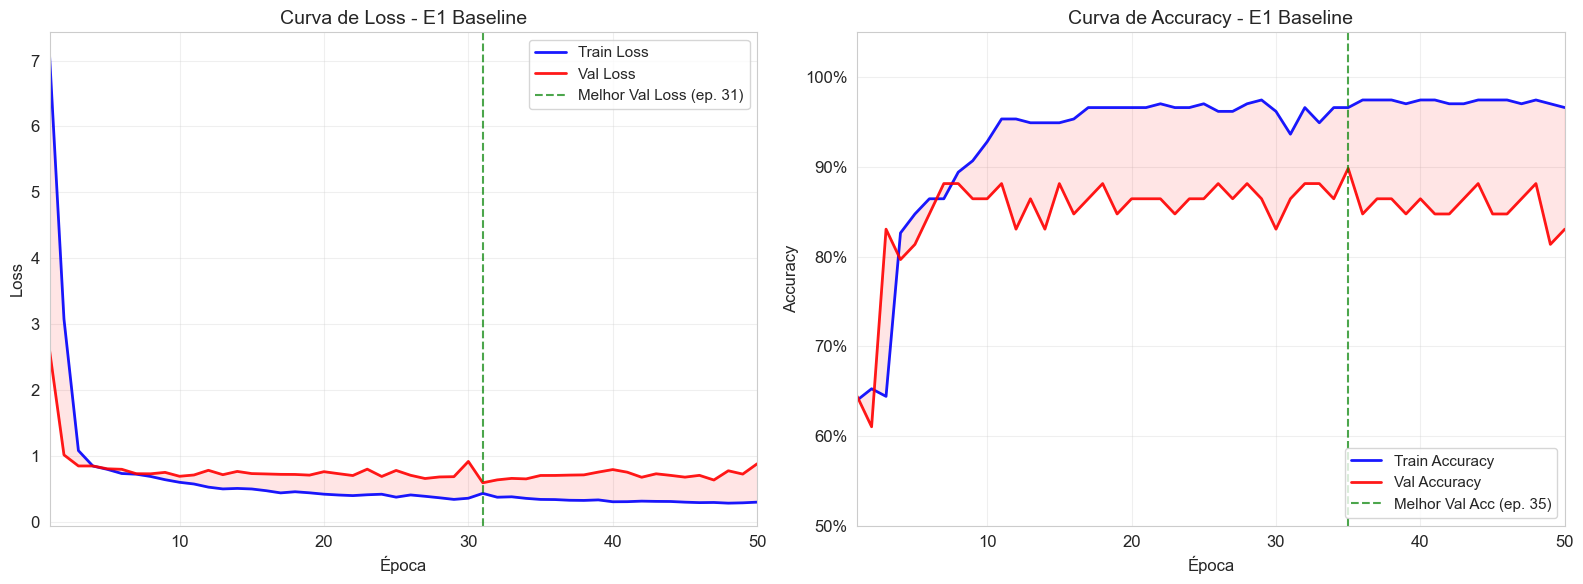

Salvo: /Users/mateus/Projetos/Academico/Inteli/g01/outputs/a06_avaliação_experimental/e1_curvas_aprendizado.png


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Loss ---
ax1 = axes[0]
ax1.plot(epochs, history['loss'], 'b-', linewidth=2, label='Train Loss', alpha=0.9)
ax1.plot(epochs, history['val_loss'], 'r-', linewidth=2, label='Val Loss', alpha=0.9)
ax1.axvline(x=best_epoch_loss, color='green', linestyle='--', alpha=0.7,
            label=f'Melhor Val Loss (ep. {best_epoch_loss})')
ax1.fill_between(epochs, history['loss'], history['val_loss'], alpha=0.1, color='red')
ax1.set_xlabel('Época')
ax1.set_ylabel('Loss')
ax1.set_title('Curva de Loss - E1 Baseline')
ax1.legend(loc='upper right')
ax1.set_xlim(1, len(epochs))
ax1.grid(True, alpha=0.3)

# --- Accuracy ---
ax2 = axes[1]
ax2.plot(epochs, history['accuracy'], 'b-', linewidth=2, label='Train Accuracy', alpha=0.9)
ax2.plot(epochs, history['val_accuracy'], 'r-', linewidth=2, label='Val Accuracy', alpha=0.9)
ax2.axvline(x=best_epoch_acc, color='green', linestyle='--', alpha=0.7,
            label=f'Melhor Val Acc (ep. {best_epoch_acc})')
ax2.fill_between(epochs, history['accuracy'], history['val_accuracy'], alpha=0.1, color='red')
ax2.set_xlabel('Época')
ax2.set_ylabel('Accuracy')
ax2.set_title('Curva de Accuracy - E1 Baseline')
ax2.legend(loc='lower right')
ax2.set_xlim(1, len(epochs))
ax2.set_ylim(0.5, 1.05)
ax2.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'e1_curvas_aprendizado.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Salvo: {OUTPUT_DIR / "e1_curvas_aprendizado.png"}')

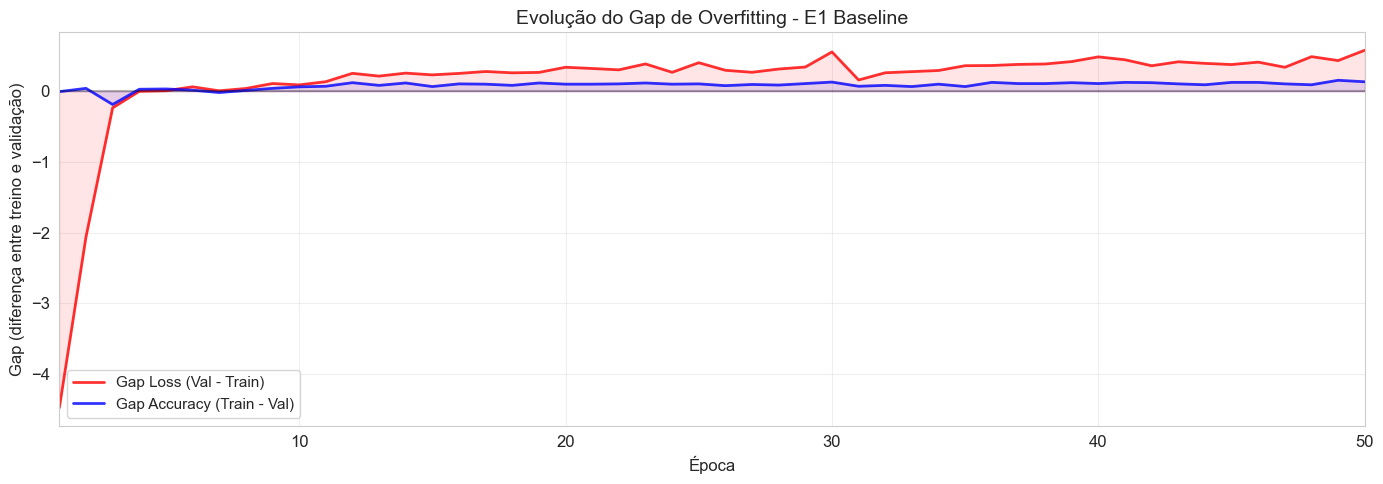

In [ ]:
# Gráfico do Gap de Overfitting ao longo do treinamento
fig, ax = plt.subplots(figsize=(14, 5))

loss_gap = [v - t for t, v in zip(history['loss'], history['val_loss'])]
acc_gap = [t - v for t, v in zip(history['accuracy'], history['val_accuracy'])]

ax.plot(epochs, loss_gap, 'r-', linewidth=2, label='Gap Loss (Val - Train)', alpha=0.8)
ax.plot(epochs, acc_gap, 'b-', linewidth=2, label='Gap Accuracy (Train - Val)', alpha=0.8)
ax.axhline(y=0, color='black', linestyle='-', alpha=0.3)
ax.fill_between(epochs, 0, loss_gap, alpha=0.1, color='red')
ax.fill_between(epochs, 0, acc_gap, alpha=0.1, color='blue')

ax.set_xlabel('Época')
ax.set_ylabel('Gap (diferença entre treino e validação)')
ax.set_title('Evolução do Gap de Overfitting - E1 Baseline')
ax.legend()
ax.set_xlim(1, len(epochs))
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'e1_overfitting_gap.png', dpi=150, bbox_inches='tight')
plt.show()

### 6.2 Métricas Detalhadas de Validação

Alem da accuracy simples, reportamos métricas que capturam diferentes aspectos do desempenho, especialmente relevantes em cenarios com desbalanceamento de classes.

In [ ]:
# Carregar métricas do log de experimentos
log_path = MODELS_DIR / 'experiments_log.csv'
df_log = pd.read_csv(log_path)

# Filtrar o E1 baseline mais recente
baseline_row = df_log[
    (df_log['config_name'] == 'baseline') &
    (df_log['experiment_dir'].str.contains(BASELINE_DIR.name))
].iloc[-1]

print('=' * 60)
print('MÉTRICAS DE VALIDAÇÃO - E1 BASELINE')
print('=' * 60)

metrics_display = [
    ('Accuracy (Val)',          baseline_row.get('val_accuracy')),
    ('Balanced Accuracy',       baseline_row.get('val_balanced_accuracy')),
    ('Precision (weighted)',    baseline_row.get('val_precision')),
    ('Recall (weighted)',       baseline_row.get('val_recall')),
    ('F1-Score (weighted)',     baseline_row.get('val_f1')),
    ('AUC-ROC',                baseline_row.get('val_auc_roc')),
    ('PR-AUC',                 baseline_row.get('val_pr_auc')),
    ('Sensitivity (TPR)',      baseline_row.get('val_sensitivity')),
    ('Specificity (TNR)',      baseline_row.get('val_specificity')),
]

for name, val in metrics_display:
    if pd.notna(val):
        print(f'  {name:30s}: {float(val):.4f} ({float(val)*100:.1f}%)')
    else:
        print(f'  {name:30s}: N/A')

MÉTRICAS DE VALIDAÇÃO - E1 BASELINE
  Accuracy (Val)                : 0.8305 (83.1%)
  Balanced Accuracy             : 0.8578 (85.8%)
  Precision (weighted)          : 0.8681 (86.8%)
  Recall (weighted)             : 0.8305 (83.1%)
  F1-Score (weighted)           : 0.8341 (83.4%)
  AUC-ROC                       : 0.7155 (71.6%)
  PR-AUC                        : 0.5461 (54.6%)
  Sensitivity (TPR)             : 0.9524 (95.2%)
  Specificity (TNR)             : 0.7632 (76.3%)


<strong>Tabela 4</strong> - Glossário de Métricas

| Métrica | Fórmula | Interpretação no Contexto |
|---|---|---|
| **Accuracy** | (TP+TN) / Total | Proporção geral de acertos; pode ser enganosa com classes desbalanceadas |
| **Balanced Accuracy** | (Sensitivity + Specificity) / 2 | Compensa desbalanceamento ao ponderar igualmente cada classe |
| **Precision** | TP / (TP+FP) | Dos tiles classificados como positivos, quantos realmente sao |
| **Recall (Sensitivity)** | TP / (TP+FN) | Dos tiles realmente positivos, quantos o modelo detectou |
| **F1-Score** | 2 * (P*R) / (P+R) | Média harmônica entre Precision e Recall |
| **AUC-ROC** | Area sob curva ROC | Capacidade de discriminação independente do threshold |
| **PR-AUC** | Area sob curva Precision-Recall | Relevante quando a classe positiva é minoritária |
| **Specificity** | TN / (TN+FP) | Capacidade de identificar corretamente tiles negativos |

<p style="font-size: 0.9em;">Fonte: Sokolova & Lapalme (2009), "A systematic analysis of performance measures for classification tasks".</p>

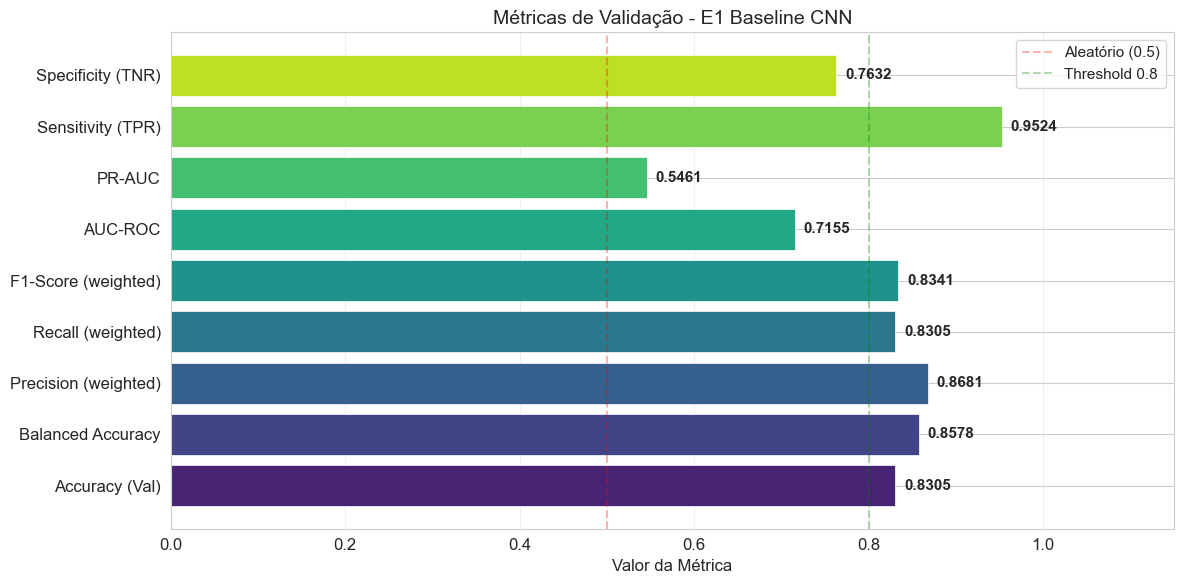

In [ ]:
# Gráfico de barras horizontais com todas as métricas
metric_names = []
metric_values = []
for name, val in metrics_display:
    if pd.notna(val):
        metric_names.append(name)
        metric_values.append(float(val))

fig, ax = plt.subplots(figsize=(12, 6))
colors = sns.color_palette('viridis', len(metric_names))
bars = ax.barh(metric_names, metric_values, color=colors, edgecolor='white', linewidth=0.5)

for bar, val in zip(bars, metric_values):
    ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=11, fontweight='bold')

ax.set_xlim(0, 1.15)
ax.set_xlabel('Valor da Métrica')
ax.set_title('Métricas de Validação - E1 Baseline CNN')
ax.axvline(x=0.5, color='red', linestyle='--', alpha=0.3, label='Aleatório (0.5)')
ax.axvline(x=0.8, color='green', linestyle='--', alpha=0.3, label='Threshold 0.8')
ax.legend()
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'e1_métricas_validação.png', dpi=150, bbox_inches='tight')
plt.show()

### 6.3 Matriz de Confusão

Matriz de Confusão (Validação, n=59):
                  Pred Neg    Pred Pos
  Real Neg (0):   TN= 29      FP=  9
  Real Pos (1):   FN=  1      TP= 20


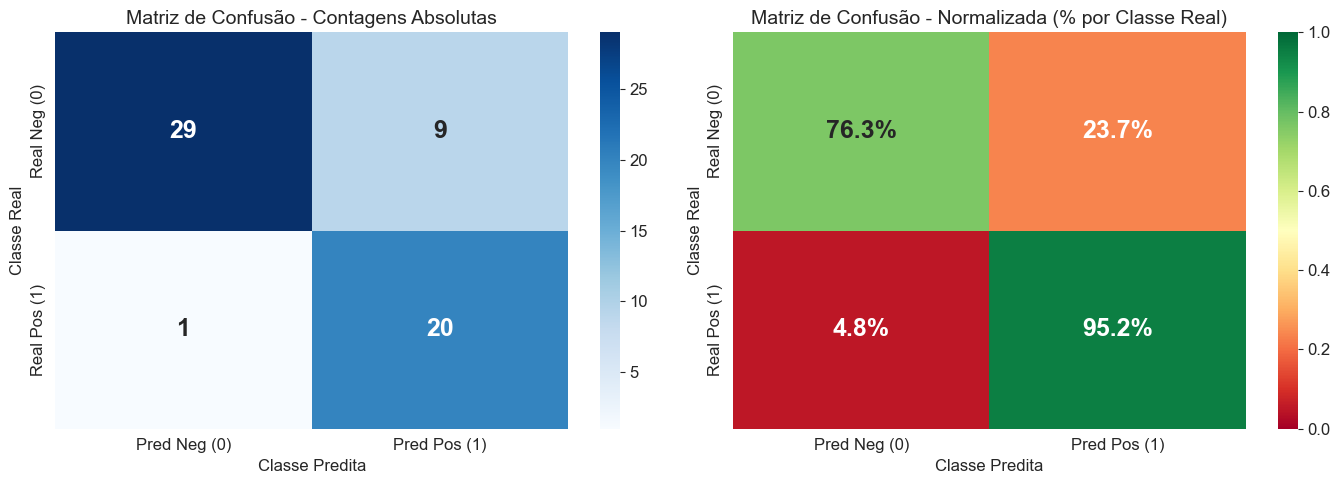

In [ ]:
# Extrair valores da matriz de confusao
tp = int(baseline_row.get('val_cm_tp', 0))
fp = int(baseline_row.get('val_cm_fp', 0))
tn = int(baseline_row.get('val_cm_tn', 0))
fn = int(baseline_row.get('val_cm_fn', 0))

cm = np.array([[tn, fp], [fn, tp]])
total_val = cm.sum()

print(f'Matriz de Confusão (Validação, n={total_val}):')
print(f'                  Pred Neg    Pred Pos')
print(f'  Real Neg (0):   TN={tn:>3d}      FP={fp:>3d}')
print(f'  Real Pos (1):   FN={fn:>3d}      TP={tp:>3d}')

# Plotar CM
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Contagens absolutas
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Pred Neg (0)', 'Pred Pos (1)'],
            yticklabels=['Real Neg (0)', 'Real Pos (1)'],
            annot_kws={'size': 18, 'weight': 'bold'})
axes[0].set_title('Matriz de Confusão - Contagens Absolutas')
axes[0].set_ylabel('Classe Real')
axes[0].set_xlabel('Classe Predita')

# Normalizada por classe real
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
sns.heatmap(cm_norm, annot=True, fmt='.1%', cmap='RdYlGn', ax=axes[1],
            xticklabels=['Pred Neg (0)', 'Pred Pos (1)'],
            yticklabels=['Real Neg (0)', 'Real Pos (1)'],
            vmin=0, vmax=1,
            annot_kws={'size': 18, 'weight': 'bold'})
axes[1].set_title('Matriz de Confusão - Normalizada (% por Classe Real)')
axes[1].set_ylabel('Classe Real')
axes[1].set_xlabel('Classe Predita')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'e1_matriz_confusao.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# Análise textual da CM
print('=' * 60)
print('ANÁLISE DA MATRIZ DE CONFUSAO - E1 BASELINE')
print('=' * 60)

print(f'\nClasse 0 (Negativo) - {tn+fp} amostras de validação:')
print(f'  Corretamente classificados (TN): {tn}/{tn+fp} ({tn/(tn+fp)*100:.1f}%)')
print(f'  Incorretamente como positivo (FP): {fp}/{tn+fp} ({fp/(tn+fp)*100:.1f}%)')

print(f'\nClasse 1 (Positivo) - {tp+fn} amostras de validação:')
print(f'  Corretamente classificados (TP): {tp}/{tp+fn} ({tp/(tp+fn)*100:.1f}%)')
print(f'  Incorretamente como negativo (FN): {fn}/{tp+fn} ({fn/(tp+fn)*100:.1f}%)')

print(f'\nInterpretação:')
print(f'  - ALTA SENSIBILIDADE ({tp/(tp+fn)*100:.1f}%): o modelo detecta quase todos os')
print(f'    tiles positivos, perdendo apenas {fn} amostra(s).')
print(f'  - ESPECIFICIDADE MODERADA ({tn/(tn+fp)*100:.1f}%): {fp} tiles negativos sao')
print(f'    incorretamente classificados como positivos (falsos alarmes).')
print(f'  - O modelo é CONSERVADOR: prefere classificar como positivo em caso de dúvida,')
print(f'    o que é desejável quando perder um positivo tem custo alto.')

ANÁLISE DA MATRIZ DE CONFUSAO - E1 BASELINE

Classe 0 (Negativo) - 38 amostras de validação:
  Corretamente classificados (TN): 29/38 (76.3%)
  Incorretamente como positivo (FP): 9/38 (23.7%)

Classe 1 (Positivo) - 21 amostras de validação:
  Corretamente classificados (TP): 20/21 (95.2%)
  Incorretamente como negativo (FN): 1/21 (4.8%)

Interpretação:
  - ALTA SENSIBILIDADE (95.2%): o modelo detecta quase todos os
    tiles positivos, perdendo apenas 1 amostra(s).
  - ESPECIFICIDADE MODERADA (76.3%): 9 tiles negativos sao
    incorretamente classificados como positivos (falsos alarmes).
  - O modelo é CONSERVADOR: prefere classificar como positivo em caso de dúvida,
    o que é desejável quando perder um positivo tem custo alto.


### 6.4 Análise de Overfitting

In [ ]:
acc_gap_final = final_train_acc - final_val_acc
loss_gap_final = final_val_loss - final_train_loss

print('=' * 60)
print('DIAGNÓSTICO DE OVERFITTING - E1 BASELINE')
print('=' * 60)

print(f'\nGap na ultima época ({len(epochs)}):')
print(f'  Train Acc: {final_train_acc:.4f}  |  Val Acc: {final_val_acc:.4f}  |  Gap: {acc_gap_final:.4f} ({acc_gap_final*100:.1f}%)')
print(f'  Train Loss: {final_train_loss:.4f} |  Val Loss: {final_val_loss:.4f} |  Gap: {loss_gap_final:.4f}')

print(f'\nÉpoca otima para early stopping:')
print(f'  Por val_loss: época {best_epoch_loss} (val_loss = {best_val_loss:.4f})')
print(f'  Por val_accuracy: época {best_epoch_acc} (val_acc = {best_val_acc:.4f})')

print(f'\nDiagnóstico:')
if acc_gap_final > 0.15:
    nível = 'SIGNIFICATIVO'
    rec = 'Aumentar regularização, usar data augmentation e/ou early stopping'
elif acc_gap_final > 0.05:
    nível = 'MODERADO'
    rec = 'Considerar early stopping e/ou data augmentation'
else:
    nível = 'BAIXO'
    rec = 'Modelo generaliza bem; manter configuração'

print(f'  Nível de overfitting: {nível} (gap = {acc_gap_final*100:.1f}%)')
print(f'  Recomendação: {rec}')

DIAGNÓSTICO DE OVERFITTING - E1 BASELINE

Gap na ultima época (50):
  Train Acc: 0.9661  |  Val Acc: 0.8305  |  Gap: 0.1356 (13.6%)
  Train Loss: 0.2987 |  Val Loss: 0.8814 |  Gap: 0.5827

Época otima para early stopping:
  Por val_loss: época 31 (val_loss = 0.5927)
  Por val_accuracy: época 35 (val_acc = 0.8983)

Diagnóstico:
  Nível de overfitting: MODERADO (gap = 13.6%)
  Recomendação: Considerar early stopping e/ou data augmentation


In [ ]:
# Tabela de evolução a cada 5 épocas
print('\nEvolução do treinamento (a cada 5 épocas):')
print(f'{"Ep":>4} | {"Train Loss":>11} | {"Val Loss":>11} | {"Train Acc":>10} | {"Val Acc":>10} | {"Gap Acc":>8}')
print('-' * 70)
for e in list(range(1, len(epochs)+1, 5)) + ([len(epochs)] if len(epochs) % 5 != 0 else []):
    idx = e - 1
    if idx < len(epochs):
        gap = history['accuracy'][idx] - history['val_accuracy'][idx]
        print(f'{e:>4} | {history["loss"][idx]:>11.4f} | {history["val_loss"][idx]:>11.4f} | '
              f'{history["accuracy"][idx]:>9.4f} | {history["val_accuracy"][idx]:>9.4f} | {gap:>7.4f}')


Evolução do treinamento (a cada 5 épocas):
  Ep |  Train Loss |    Val Loss |  Train Acc |    Val Acc |  Gap Acc
----------------------------------------------------------------------
   1 |      7.0883 |      2.6069 |    0.6398 |    0.6441 | -0.0042
   6 |      0.7332 |      0.7973 |    0.8644 |    0.8475 |  0.0169
  11 |      0.5742 |      0.7110 |    0.9534 |    0.8814 |  0.0720
  16 |      0.4725 |      0.7267 |    0.9534 |    0.8475 |  0.1059
  21 |      0.4071 |      0.7311 |    0.9661 |    0.8644 |  0.1017
  26 |      0.4080 |      0.7064 |    0.9619 |    0.8814 |  0.0805
  31 |      0.4318 |      0.5927 |    0.9364 |    0.8644 |  0.0720
  36 |      0.3379 |      0.7041 |    0.9746 |    0.8475 |  0.1271
  41 |      0.3058 |      0.7535 |    0.9746 |    0.8475 |  0.1271
  46 |      0.2915 |      0.7054 |    0.9746 |    0.8475 |  0.1271


---
## 6b. E4 - Experimento de Arquitetura: Variação de Profundidade

**Hipótese:** Adicionar uma terceira camada convolucional (128 filtros) permite que a rede aprenda representações hierárquicas mais complexas das imagens multiespectrais ASTER.

**Variável independente:** Profundidade da rede (número de blocos Conv2D)

| Parâmetro | Baseline (E1) | Deeper (E4) |
|-----------|--------------|-------------|
| Filtros Conv | [32, 64] | [32, 64, 128] |
| Blocos Conv | 2 | 3 |
| MaxPooling | 2 | 3 |
| Feature map final | 32x32x64 | 16x16x128 |
| Total de parâmetros | ~1.2M | ~4.3M |

**Variáveis controladas:** lr=0.001, batch=32, epochs=50, L2=0.001, conv_dropout=0.2, dense_dropout=0.5.

**Config:** `src/models/configs/deeper_arch.yaml`
**Notebook de execução:** `notebooks/e04_architecture.ipynb`
**Diretório de resultados:** `outputs/trained_models/deeper_arch_20260312_094802/`

In [ ]:
# E4: Carregar histórico do experimento deeper_arch
deeper_dirs = sorted(MODELS_DIR.glob('deeper_arch_*'))
if deeper_dirs:
    DEEPER_DIR = deeper_dirs[-1]
    print(f'Experimento E4: {DEEPER_DIR.name}')
    
    with open(DEEPER_DIR / 'config_used.json') as f:
        config_e4 = json.load(f)
    with open(DEEPER_DIR / 'history.json') as f:
        history_e4 = json.load(f)
    
    print(f"  Filtros: {config_e4['model']['filters']}")
    print(f"  Epochs treinados: {len(history_e4['loss'])}")
    print(f"  Final train acc: {history_e4['accuracy'][-1]:.4f}")
    print(f"  Final val acc: {history_e4['val_accuracy'][-1]:.4f}")
else:
    print('Nenhum experimento deeper_arch encontrado. Execute notebooks/e04_architecture.ipynb primeiro.')

### 6b.1 Curvas de Aprendizado - E4 vs E1 (Baseline)

In [ ]:
# Curvas de aprendizado comparativas: E1 (Baseline) vs E4 (Deeper)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Loss
ax = axes[0]
ax.plot(history['loss'], label='Baseline - Train', color='steelblue', linestyle='--')
ax.plot(history['val_loss'], label='Baseline - Val', color='steelblue')
ax.plot(history_e4['loss'], label='Deeper - Train', color='coral', linestyle='--')
ax.plot(history_e4['val_loss'], label='Deeper - Val', color='coral')
ax.set_title('Loss: Baseline (2 Conv) vs Deeper (3 Conv)', fontsize=13)
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.legend()
ax.grid(True, alpha=0.3)

# Accuracy
ax = axes[1]
ax.plot(history['accuracy'], label='Baseline - Train', color='steelblue', linestyle='--')
ax.plot(history['val_accuracy'], label='Baseline - Val', color='steelblue')
ax.plot(history_e4['accuracy'], label='Deeper - Train', color='coral', linestyle='--')
ax.plot(history_e4['val_accuracy'], label='Deeper - Val', color='coral')
ax.set_title('Accuracy: Baseline (2 Conv) vs Deeper (3 Conv)', fontsize=13)
ax.set_xlabel('Epoch')
ax.set_ylabel('Accuracy')
ax.legend()
ax.grid(True, alpha=0.3)

plt.suptitle('E4 - Impacto da Profundidade da Rede', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### 6b.2 Métricas Comparativas E4 vs E1

In [ ]:
# Tabela comparativa E1 vs E4 usando experiments_log.csv
df_log_e4 = pd.read_csv(MODELS_DIR / 'experiments_log.csv')

baseline_last = df_log_e4[df_log_e4['config_name'] == 'baseline'].iloc[-1]
deeper_last = df_log_e4[df_log_e4['config_name'] == 'deeper_arch'].iloc[-1]

metrics_compare = [
    ('val_acc', 'Val Accuracy (Keras)'),
    ('val_accuracy', 'Val Accuracy (sklearn)'),
    ('val_f1', 'F1-Score'),
    ('val_precision', 'Precision'),
    ('val_recall', 'Recall'),
    ('val_balanced_accuracy', 'Balanced Accuracy'),
    ('val_auc_roc', 'AUC-ROC'),
    ('val_sensitivity', 'Sensitivity'),
    ('val_specificity', 'Specificity'),
    ('train_loss', 'Train Loss'),
    ('val_loss', 'Val Loss'),
]

print(f"{'Métrica':<25} {'Baseline (E1)':<18} {'Deeper (E4)':<18} {'Delta':<12}")
print('=' * 73)
for col, name in metrics_compare:
    b_val = baseline_last.get(col, None)
    d_val = deeper_last.get(col, None)
    try:
        b_val = float(b_val)
        d_val = float(d_val)
        delta = d_val - b_val
        sign = '+' if delta >= 0 else ''
        print(f'{name:<25} {b_val:<18.4f} {d_val:<18.4f} {sign}{delta:<12.4f}')
    except (TypeError, ValueError):
        print(f'{name:<25} {str(b_val):<18} {str(d_val):<18} {"N/A":<12}')

In [ ]:
# Gráfico de barras comparativo E1 vs E4
metrics_for_bar = ['val_accuracy', 'val_f1', 'val_precision', 'val_recall', 'val_balanced_accuracy']
metric_labels_bar = ['Accuracy', 'F1-Score', 'Precision', 'Recall', 'Bal. Accuracy']

b_vals = [float(baseline_last.get(m, 0)) for m in metrics_for_bar]
d_vals = [float(deeper_last.get(m, 0)) for m in metrics_for_bar]

x = np.arange(len(metric_labels_bar))
w = 0.35

fig, ax = plt.subplots(figsize=(12, 6))
bars1 = ax.bar(x - w/2, b_vals, w, label='Baseline E1 (2 Conv)', color='steelblue', alpha=0.85)
bars2 = ax.bar(x + w/2, d_vals, w, label='Deeper E4 (3 Conv)', color='coral', alpha=0.85)

ax.set_ylabel('Score')
ax.set_title('E4 - Comparação de Métricas: Baseline vs Deeper Architecture', fontsize=13)
ax.set_xticks(x)
ax.set_xticklabels(metric_labels_bar)
ax.legend()
ax.set_ylim(0, 1.15)
ax.grid(axis='y', alpha=0.3)

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

### 6b.3 Análise de Overfitting - E4 vs E1

In [ ]:
# Análise de overfitting comparativa E1 vs E4
print('=== Análise de Overfitting: E1 (Baseline) vs E4 (Deeper) ===\n')

for name, hist in [('Baseline (E1)', history), ('Deeper (E4)', history_e4)]:
    final_train_acc = hist['accuracy'][-1]
    final_val_acc = hist['val_accuracy'][-1]
    final_train_loss = hist['loss'][-1]
    final_val_loss = hist['val_loss'][-1]
    acc_gap = final_train_acc - final_val_acc
    loss_gap = final_val_loss - final_train_loss
    best_val_epoch = int(np.argmax(hist['val_accuracy'])) + 1
    best_val_acc = max(hist['val_accuracy'])

    print(f'--- {name} ---')
    print(f'  Train acc: {final_train_acc:.4f} | Val acc: {final_val_acc:.4f} | Gap: {acc_gap:.4f}')
    print(f'  Train loss: {final_train_loss:.4f} | Val loss: {final_val_loss:.4f} | Gap: {loss_gap:.4f}')
    print(f'  Melhor val_acc: {best_val_acc:.4f} (epoch {best_val_epoch})')
    if acc_gap > 0.15:
        print(f'  ⚠️ Overfitting significativo detectado (gap > 15%)')
    elif acc_gap > 0.10:
        print(f'  ⚠️ Overfitting moderado (gap 10-15%)')
    else:
        print(f'  ✓ Overfitting controlado (gap < 10%)')
    print()

### 6b.4 Conclusão do E4

**Resultado:** A arquitetura mais profunda (3 Conv: [32, 64, 128]) apresentou **resultados mistos** em relação ao baseline (2 Conv: [32, 64]) — ganhos marginais em accuracy, mas perdas significativas em AUC-ROC e sensibilidade.

| Métrica | Baseline (E1) | Deeper (E4) | Delta |
|---------|--------------|-------------|-------|
| Val Accuracy | 83.05% | 84.75% | +1.7pp |
| F1-Score | 0.834 | 0.849 | +0.015 |
| AUC-ROC | 0.716 | 0.604 | -0.112 |
| Sensitivity | 95.24% | 85.71% | -9.5pp |
| Specificity | 76.32% | 84.21% | +7.9pp |
| Val Loss | 0.881 | 0.951 | +0.070 |
| CM (TP/FP/TN/FN) | 20/9/29/1 | 18/6/32/3 | |

**Análise:**
- O modelo deeper é mais conservador: melhor em rejeitar negativos (specificity +7.9pp), mas perde mais positivos (sensitivity -9.5pp, FN subiu de 1→3)
- AUC-ROC caiu 11.2pp, indicando calibração de probabilidades degradada — o modelo deeper produz scores menos discriminativos
- Melhor val_acc idêntica para ambos (89.83% no epoch 35), porém val_loss do deeper é consistentemente maior, sinalizando overfitting em loss
- Com 4.3M params (vs ~1.2M baseline) e apenas 236 amostras de treino, a capacidade extra não se converte em generalização
- O gargalo Flatten(32.768)→Dense(128) comprime 99.6% da informação, amplificando ruído

**Decisão:** Manter arquitetura baseline (2 Conv). Para detecção ambiental, a perda de sensibilidade (-9.5pp) não justifica o ganho marginal em accuracy (+1.7pp). Recomenda-se explorar Global Average Pooling ou data augmentation antes de adicionar profundidade.

---
## 7. Histórico Completo de Experimentos

Todos os experimentos executados ao longo do projeto foram registrados automaticamente em `outputs/trained_models/experiments_log.csv`. Esta seção consolida e compara todos os resultados.

In [ ]:
# Tabela completa de experimentos
df_log = pd.read_csv(MODELS_DIR / 'experiments_log.csv')

print(f'Total de execuções registradas: {len(df_log)}')
print(f'Configurações utilizadas: {df_log["config_name"].unique().tolist()}')
print(f'Período: {df_log["timestamp"].iloc[0]} a {df_log["timestamp"].iloc[-1]}')
print()

# Exibir tabela resumida
cols_show = ['timestamp', 'config_name', 'train_loss', 'train_acc', 'val_loss', 'val_acc', 'epochs']
cols_avail = [c for c in cols_show if c in df_log.columns]
display(df_log[cols_avail].round(4))

Total de execuções registradas: 21
Configurações utilizadas: ['baseline', 'higher_dropout', 'l2batch', 'l2batch32']
Período: 2026-03-09 22:17:16 a 2026-03-11 08:38:34



,timestamp,config_name,train_loss,train_acc,val_loss,val_acc,epochs
0,2026-03-09 22:17:16,baseline,0.3178,0.9875,1.2867,0.8500,50
1,2026-03-09 22:19:01,baseline,0.3334,0.9875,1.3967,0.8500,50
2,2026-03-05 10:56:43,baseline,0.6442,0.8750,0.5554,1.0000,50
3,2026-03-05 10:57:56,baseline,0.5748,0.8750,0.5315,1.0000,50
4,2026-03-05 10:59:05,higher_dropout,0.5872,0.8750,0.5179,1.0000,50
5,2026-03-05 11:01:01,baseline,0.5898,0.8750,0.4965,1.0000,50
6,2026-03-05 11:02:28,baseline,0.6050,0.8750,0.5560,1.0000,50
7,2026-03-05 11:03:53,higher_dropout,0.5837,0.8750,0.7663,1.0000,50
8,2026-03-05 11:09:52,l2batch,0.6903,0.8750,0.6488,1.0000,50
9,2026-03-05 11:11:05,baseline,0.6190,0.8750,0.5209,1.0000,50


In [ ]:
# Melhor resultado por configuração
best_per_config = df_log.groupby('config_name').agg({
    'val_acc': 'max',
    'train_acc': 'max',
    'val_loss': 'min',
    'train_loss': 'min',
}).round(4)

print('Melhor resultado por configuração:')
display(best_per_config)

# Número de execuções por config
print('\nNúmero de execuções por configuração:')
print(df_log['config_name'].value_counts().to_string())

Melhor resultado por configuração:


,val_acc,train_acc,val_loss,train_loss
config_name,,,,
baseline,1.0,0.9875,0.4965,0.2987
higher_dropout,1.0,0.9875,0.5179,0.2758
l2batch,1.0,0.9875,0.6292,0.4659
l2batch32,1.0,0.8750,0.4329,0.5205



Número de execuções por configuração:
config_name
baseline          9
l2batch           7
higher_dropout    4
l2batch32         1


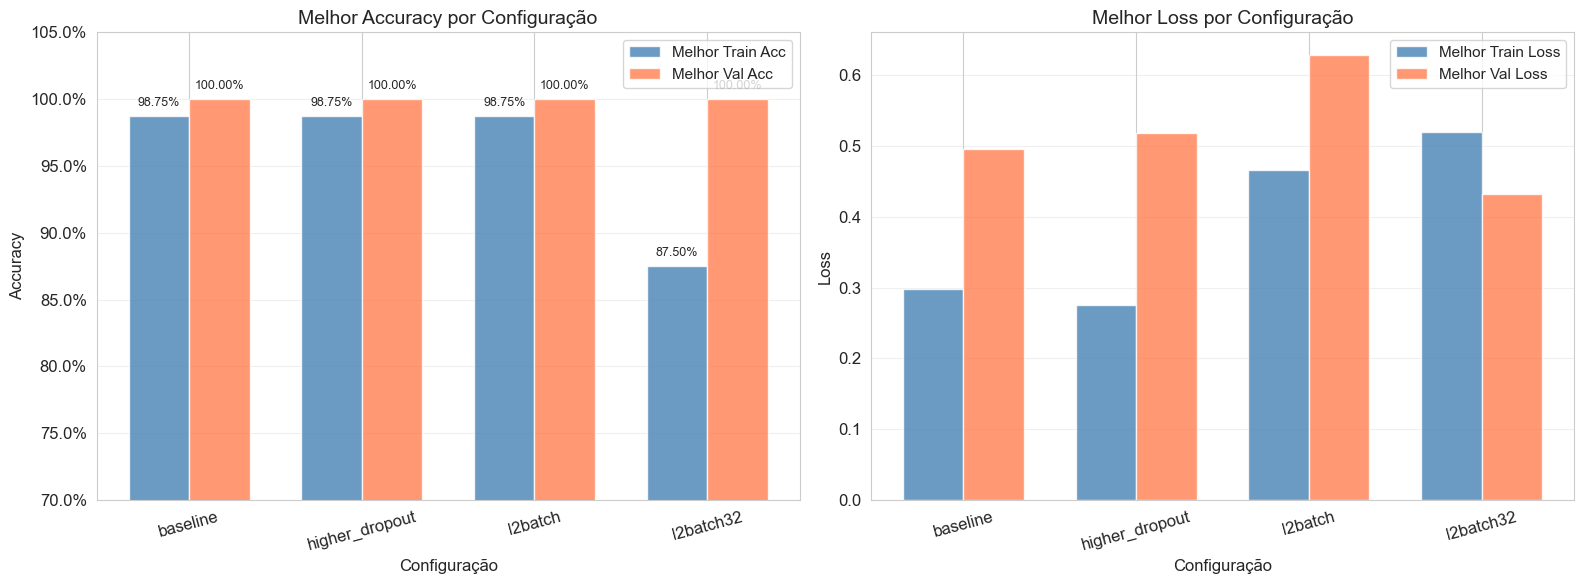

In [ ]:
# Gráfico comparativo: melhor val_acc por configuração
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Accuracy ---
ax = axes[0]
x = np.arange(len(best_per_config))
width = 0.35
bars1 = ax.bar(x - width/2, best_per_config['train_acc'], width,
               label='Melhor Train Acc', color='steelblue', alpha=0.8)
bars2 = ax.bar(x + width/2, best_per_config['val_acc'], width,
               label='Melhor Val Acc', color='coral', alpha=0.8)
ax.set_xlabel('Configuração')
ax.set_ylabel('Accuracy')
ax.set_title('Melhor Accuracy por Configuração')
ax.set_xticks(x)
ax.set_xticklabels(best_per_config.index, rotation=15)
ax.legend()
ax.set_ylim(0.7, 1.05)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax.grid(axis='y', alpha=0.3)
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.2%}', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.2%}', ha='center', va='bottom', fontsize=9)

# --- Loss ---
ax2 = axes[1]
bars3 = ax2.bar(x - width/2, best_per_config['train_loss'], width,
                label='Melhor Train Loss', color='steelblue', alpha=0.8)
bars4 = ax2.bar(x + width/2, best_per_config['val_loss'], width,
                label='Melhor Val Loss', color='coral', alpha=0.8)
ax2.set_xlabel('Configuração')
ax2.set_ylabel('Loss')
ax2.set_title('Melhor Loss por Configuração')
ax2.set_xticks(x)
ax2.set_xticklabels(best_per_config.index, rotation=15)
ax2.legend()
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'comparação_configs.png', dpi=150, bbox_inches='tight')
plt.show()

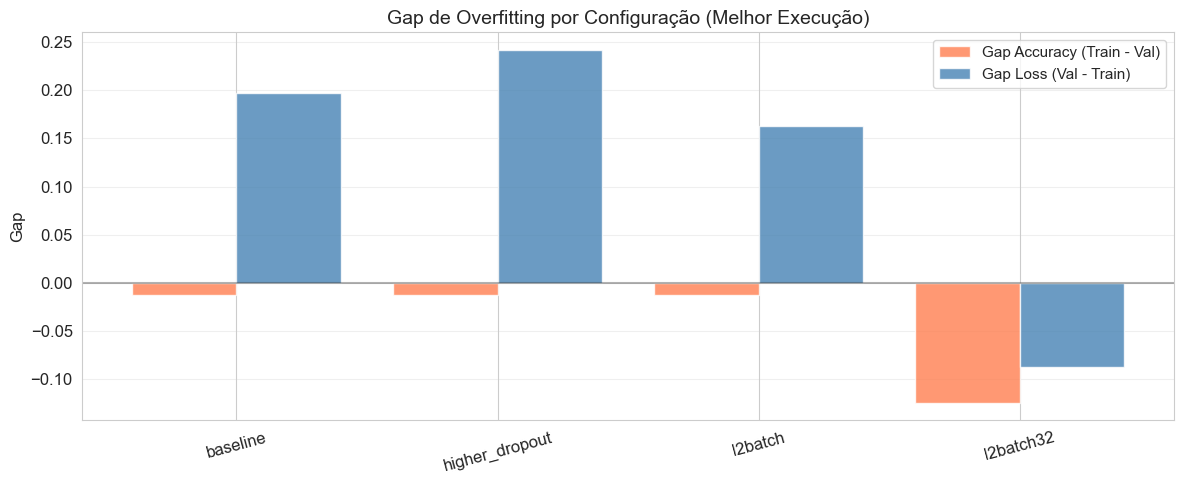

In [ ]:
# Gráfico: Gap de overfitting por configuração (melhor execução)
fig, ax = plt.subplots(figsize=(12, 5))

gap_data = best_per_config.copy()
gap_data['acc_gap'] = gap_data['train_acc'] - gap_data['val_acc']
gap_data['loss_gap'] = gap_data['val_loss'] - gap_data['train_loss']

x = np.arange(len(gap_data))
ax.bar(x - 0.2, gap_data['acc_gap'], 0.4, label='Gap Accuracy (Train - Val)', color='coral', alpha=0.8)
ax.bar(x + 0.2, gap_data['loss_gap'], 0.4, label='Gap Loss (Val - Train)', color='steelblue', alpha=0.8)

ax.set_xticks(x)
ax.set_xticklabels(gap_data.index, rotation=15)
ax.set_ylabel('Gap')
ax.set_title('Gap de Overfitting por Configuração (Melhor Execução)')
ax.axhline(y=0, color='black', linestyle='-', alpha=0.3)
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'overfitting_por_config.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 8. Comparação com Baselines Anteriores

Para contextualizar o desempenho da CNN, comparamos com os modelos anteriores:

- **A02 (Baseline Classico)**: Modelos tradicionais de ML (Random Forest, SVM, etc.) treinados sobre features agregadas por banda
- **A03 (MLP Baseline)**: Rede neural densa (Multi-Layer Perceptron) com 2 camadas ocultas, treinada sobre medias por banda + PCA

### Contexto Importante

Os modelos A02 é A03 utilizam **features agregadas** (medias por banda, PCA), enquanto a CNN processa os **tiles completos** (128x128x9). Isso significa que a CNN tem acesso a informação espacial que os modelos anteriores não possuem.

In [ ]:
# Tabela comparativa entre modelos
# Valores dos baselines anteriores extraidos dos artefatos A02 é A03
comparison_data = {
    'Modelo': [
        'A02 - Baseline Classico (melhor)',
        'A03 - MLP Baseline',
        'A06 - CNN Baseline (E1)',
    ],
    'Tipo': [
        'ML Tradicional',
        'MLP (2 camadas)',
        'CNN (2 Conv + 1 Dense)',
    ],
    'Input': [
        'Features agregadas',
        '9 medias por banda + PCA',
        'Tile 128x128x9 (completo)',
    ],
    'Val/Test Accuracy': [
        0.81,   # A02 melhor modelo no teste
        0.76,   # A03 MLP no teste
        round(float(baseline_row.get('val_accuracy', 0)), 4),  # A06 E1 na validação
    ],
    'F1-Score': [
        0.81,   # A02
        0.77,   # A03
        round(float(baseline_row.get('val_f1', 0)), 4),
    ],
    'AUC-ROC': [
        0.88,   # A02 (melhor modelo)
        0.91,   # A03
        round(float(baseline_row.get('val_auc_roc', 0)), 4),
    ],
    'Parâmetros': [
        'N/A (nao-parametrico)',
        '~2,305',
        f'~{model.count_params():,}',
    ],
}

df_comparison = pd.DataFrame(comparison_data)
print('=' * 90)
print('COMPARAÇÃO ENTRE MODELOS DO PROJETO')
print('=' * 90)
display(df_comparison)

COMPARAÇÃO ENTRE MODELOS DO PROJETO


,Modelo,Tipo,Input,Val/Test Accuracy,F1-Score,AUC-ROC,Parâmetros
0,A02 - Baseline Classico (melhor),ML Tradicional,Features agregadas,0.8100,0.8100,0.8800,N/A (nao-parametrico)
1,A03 - MLP Baseline,MLP (2 camadas),9 medias por banda + PCA,0.7600,0.7700,0.9100,"~2,305"
2,A06 - CNN Baseline (E1),CNN (2 Conv + 1 Dense),Tile 128x128x9 (completo),0.8305,0.8341,0.7155,"~8,410,114"


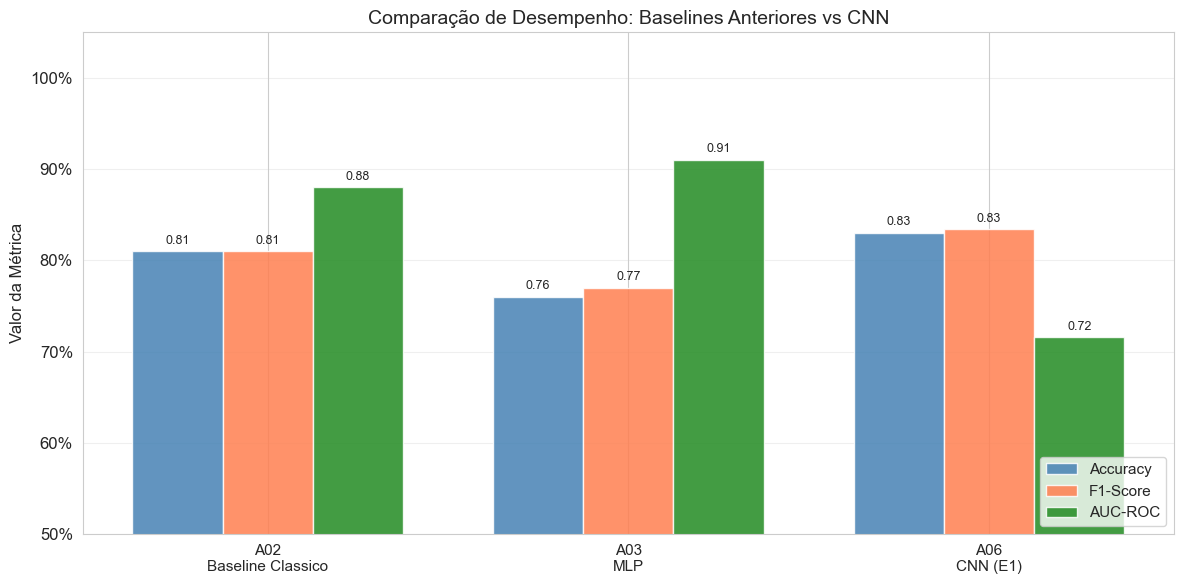

In [ ]:
# Gráfico comparativo entre modelos
fig, ax = plt.subplots(figsize=(12, 6))

models = df_comparison['Modelo'].tolist()
x = np.arange(len(models))
w = 0.25

acc_vals = df_comparison['Val/Test Accuracy'].tolist()
f1_vals = df_comparison['F1-Score'].tolist()
auc_vals = df_comparison['AUC-ROC'].tolist()

bars_acc = ax.bar(x - w, acc_vals, w, label='Accuracy', color='steelblue', alpha=0.85)
bars_f1 = ax.bar(x, f1_vals, w, label='F1-Score', color='coral', alpha=0.85)
bars_auc = ax.bar(x + w, auc_vals, w, label='AUC-ROC', color='forestgreen', alpha=0.85)

for bars in [bars_acc, bars_f1, bars_auc]:
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(['A02\nBaseline Classico', 'A03\nMLP', 'A06\nCNN (E1)'], fontsize=11)
ax.set_ylabel('Valor da Métrica')
ax.set_title('Comparação de Desempenho: Baselines Anteriores vs CNN')
ax.legend(loc='lower right')
ax.set_ylim(0.5, 1.05)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'comparação_modelos.png', dpi=150, bbox_inches='tight')
plt.show()

### Análise Comparativa

**Observações importantes sobre a comparação:**

1. **Conjuntos diferentes**: A02/A03 reportam métricas no conjunto de *teste* (hold-out separado), enquanto A06 reporta na *validação* (split interno). Isso dificulta comparação direta, mas fornece uma referência util.

2. **Features vs. Pixels brutos**: A CNN processa tiles completos (128x128x9 = 147.456 valores por amostra), tendo acesso a informação espacial. Os baselines usam features agregadas (9 medias por banda), perdendo toda a informação espacial.

3. **Complexidade**: A CNN tem ordens de magnitude mais parâmetros que o MLP, o que explica tanto seu potencial de desempenho quanto sua tendência a overfitting com poucos dados (295 amostras).

4. **AUC-ROC**: O AUC-ROC da CNN (E1) está abaixo dos baselines, sugerindo que o threshold padrao de 0.5 pode não ser ótimo e que o ranking de probabilidades pode melhorar com mais dados ou regularização.